# Whose Sharpe Is It? \U0001F310
### The same fund. The same shares. Six different answers.

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

Every performance statistic you have ever read was computed in some currency, almost always
dollars, almost always without saying so. If you do not spend dollars, the number is not about
you — and the gap is bigger than most people would guess.

> \U0001F4D3 **This is the plain-language layer.** The variance identity, the three-way
> decomposition and the hedge ratios are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does your currency change a fund's Sharpe? | Substantially. |
| Is that just the exchange rate drifting? | No — a third of it is pure added risk. |
| Does it change which fund looks best? | Sometimes, yes. |
| Should you hedge? | For the risk reduction, usually. For the return, no. |

## 1 · One fund, six investors

In [2]:
from whosesharpe import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
fx_rets = {k: rets[v].dropna() for k, v in data.FX.items()
           if v in rets.columns and rets[v].notna().sum() > 1000}
asset = rets[data.ASSET].dropna()
common = asset.index
for f in fx_rets.values():
    common = common.intersection(f.index)
asset = asset.reindex(common).dropna()
usd_rf = rets[data.CASH].reindex(asset.index).fillna(0.0)
fx_rets = {k: v.reindex(asset.index).dropna() for k, v in fx_rets.items()}
tbl = st.sharpe_by_currency(asset, fx_rets, usd_rf)
print(f"as-of {data.AS_OF} | {data.ASSET}, {asset.index[0].date()} -> "
      f"{asset.index[-1].date()} ({len(asset) / 252:.1f} years)")
print(tbl[["cagr", "vol", "rf_ann", "sharpe"]].round(4).to_string())

as-of 2026-06-30 | SPY, 2007-02-14 -> 2026-06-30 (19.3 years)
           cagr    vol  rf_ann  sharpe
currency                              
USD      0.1089 0.1969  0.0134  0.4554
EUR      0.1144 0.1961  0.0229  0.4346
GBP      0.1230 0.1913  0.0271  0.4651
JPY      0.1310 0.2476  0.0310  0.3714
CHF      0.0901 0.2217  0.0090  0.3479
AUD      0.0959 0.1638  0.0193  0.4413
CAD      0.1142 0.1721  0.0217  0.5021


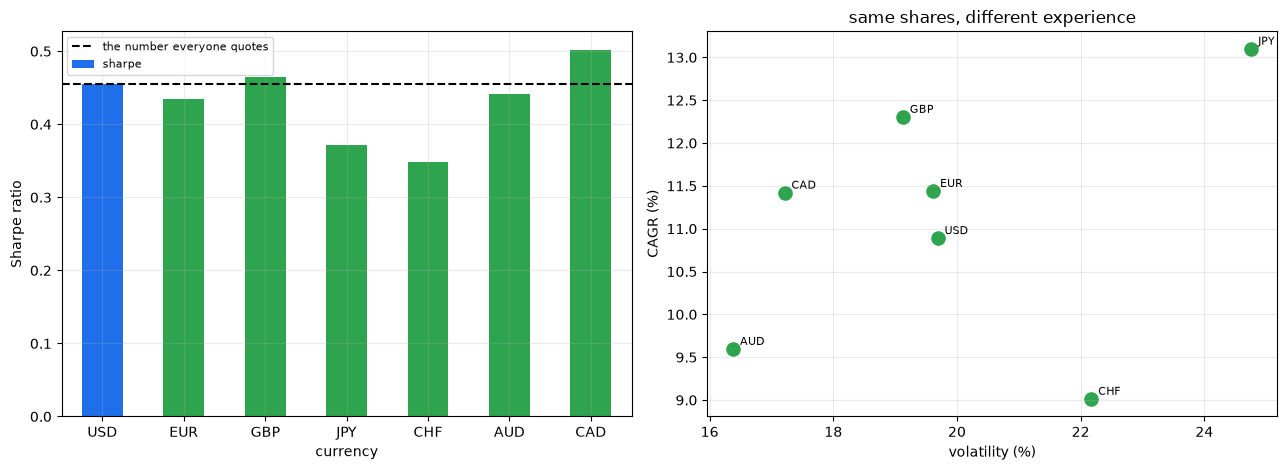

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
tbl["sharpe"].plot.bar(ax=axes[0], color=["#1f6feb"] + ["#2ea44f"] * (len(tbl) - 1))
axes[0].axhline(tbl.loc["USD", "sharpe"], color="k", ls="--", lw=1.5,
                label="the number everyone quotes")
axes[0].set_ylabel("Sharpe ratio"); axes[0].legend(fontsize=8)
plt.setp(axes[0].get_xticklabels(), rotation=0)
axes[1].scatter(tbl["vol"] * 100, tbl["cagr"] * 100, s=90, color="#2ea44f")
for cur, row in tbl.iterrows():
    axes[1].annotate(cur, (row["vol"] * 100, row["cagr"] * 100), fontsize=8,
                     xytext=(5, 3), textcoords="offset points")
axes[1].set_xlabel("volatility (%)"); axes[1].set_ylabel("CAGR (%)")
axes[1].set_title("same shares, different experience")
plt.tight_layout(); plt.show()

> \U0001F52C **For the quants.** Note the `rf_ann` column in the table above. Each investor's
> Sharpe is computed against *their own* cash rate, not the US Treasury bill. That correction is
> almost never made and it matters by tenths of a Sharpe point.

## 2 · Why the volatility goes up

This part is arithmetic, not opinion. If you hold a dollar asset and spend euros, your return is
the asset minus the currency — and the variance of a difference is

`var(a − c) = var(a) + var(c) − 2·cov(a, c)`

Unless the currency reliably rises when the asset rises, you have just added risk.

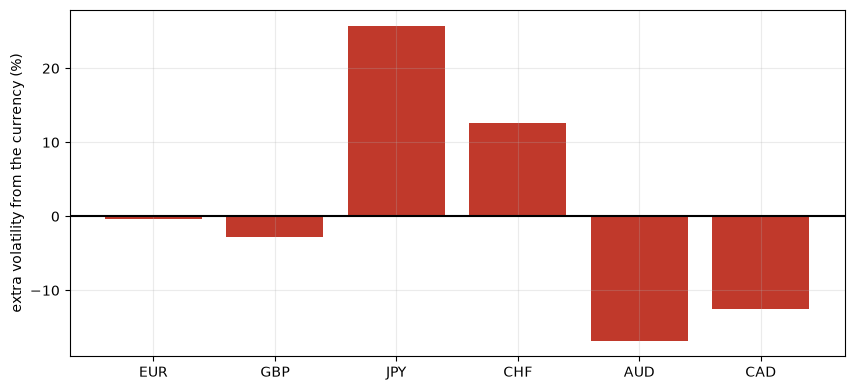

          correlation  vol in USD  vol at home  ratio
currency                                             
EUR            0.2350      0.1969       0.1961 0.9963
GBP            0.3008      0.1969       0.1913 0.9715
JPY           -0.3115      0.1969       0.2476 1.2576
CHF            0.0004      0.1969       0.2217 1.1262
AUD            0.5615      0.1969       0.1638 0.8320
CAD            0.4887      0.1969       0.1721 0.8742


In [4]:
rows = []
for k, f in fx_rets.items():
    d = st.variance_decomposition(asset, f)
    rows.append({"currency": k, "correlation": d["corr"], "vol in USD": d["vol_asset"],
                 "vol at home": d["vol_converted"], "ratio": d["vol_ratio"]})
d = pd.DataFrame(rows).set_index("currency")
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(range(len(d)), (d["ratio"] - 1) * 100, color="#c0392b")
ax.axhline(0, color="k", lw=1.5)
ax.set_xticks(range(len(d))); ax.set_xticklabels(d.index)
ax.set_ylabel("extra volatility from the currency (%)")
plt.show()
print(d.round(4).to_string())

## 3 · Drift, variance, or rates?

Three different reasons a currency changes your Sharpe, and only one of them is durable.

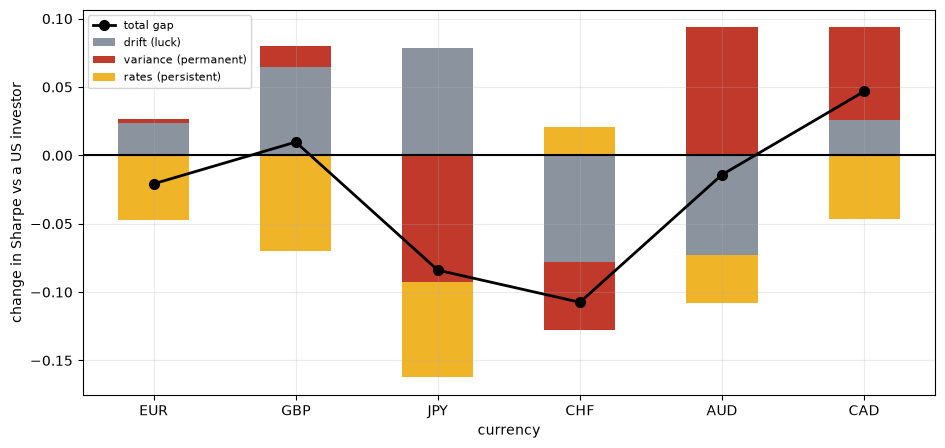

          drift (luck)  variance (permanent)  rates (persistent)   total
currency                                                                
EUR             0.0238                0.0029             -0.0474 -0.0208
GBP             0.0648                0.0152             -0.0703  0.0097
JPY             0.0785               -0.0923             -0.0702 -0.0840
CHF            -0.0777               -0.0504              0.0206 -0.1075
AUD            -0.0727                0.0936             -0.0350 -0.0141
CAD             0.0259                0.0676             -0.0468  0.0468


In [5]:
rows = []
for k, f in fx_rets.items():
    dd = st.decompose_sharpe_gap(asset, f, usd_rf)
    rows.append({"currency": k, "drift (luck)": dd["drift_term"],
                 "variance (permanent)": dd["variance_term"],
                 "rates (persistent)": dd["rate_term"], "total": dd["gap"]})
d = pd.DataFrame(rows).set_index("currency")
fig, ax = plt.subplots(figsize=(11, 5))
d[["drift (luck)", "variance (permanent)", "rates (persistent)"]].plot.bar(
    ax=ax, stacked=True, color=["#8b949e", "#c0392b", "#f0b429"])
ax.plot(range(len(d)), d["total"], "ko-", lw=2, ms=7, label="total gap")
ax.axhline(0, color="k", lw=1.5)
ax.set_ylabel("change in Sharpe vs a US investor"); ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()
print(d.round(4).to_string())

The grey bars are the dollar's wanderings over one particular eighteen years. Nobody should plan
around them. The red bars are arithmetic and will be there next decade too.

## 4 · Does it change which fund wins?

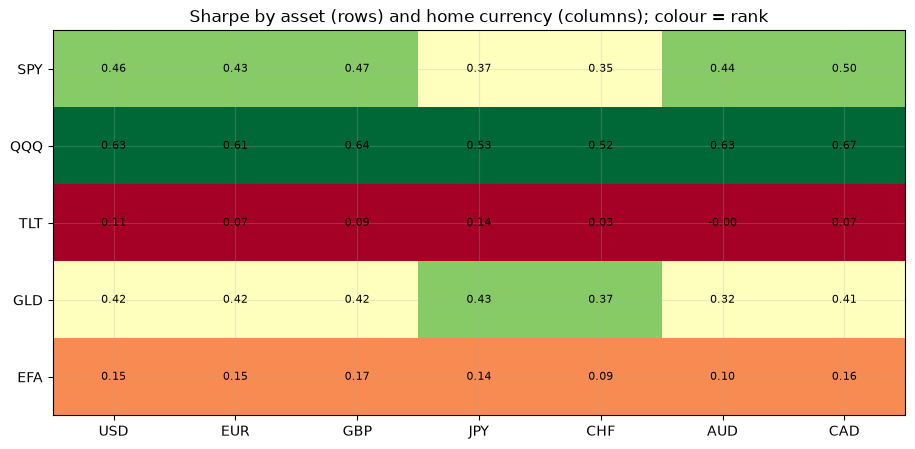

best asset by home currency:
  USD: QQQ
  EUR: QQQ
  GBP: QQQ
  JPY: QQQ
  CHF: QQQ
  AUD: QQQ
  CAD: QQQ


In [6]:
assets = {tk: rets[tk].reindex(asset.index).dropna()
          for tk in (data.ASSET,) + data.ALT_ASSETS if tk in rets.columns}
assets = {k: v for k, v in assets.items() if len(v) > 1000}
rank = st.ranking_stability(assets, fx_rets, usd_rf)
body = rank.drop("_rank_spread")
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(body.rank(ascending=False).values, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(body.shape[1])); ax.set_xticklabels(body.columns)
ax.set_yticks(range(body.shape[0])); ax.set_yticklabels(body.index)
for i in range(body.shape[0]):
    for j in range(body.shape[1]):
        ax.text(j, i, f"{body.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Sharpe by asset (rows) and home currency (columns); colour = rank")
plt.show()
print("best asset by home currency:")
for c in body.columns:
    print(f"  {c}: {body[c].idxmax()}")

## 5 · Should you hedge?

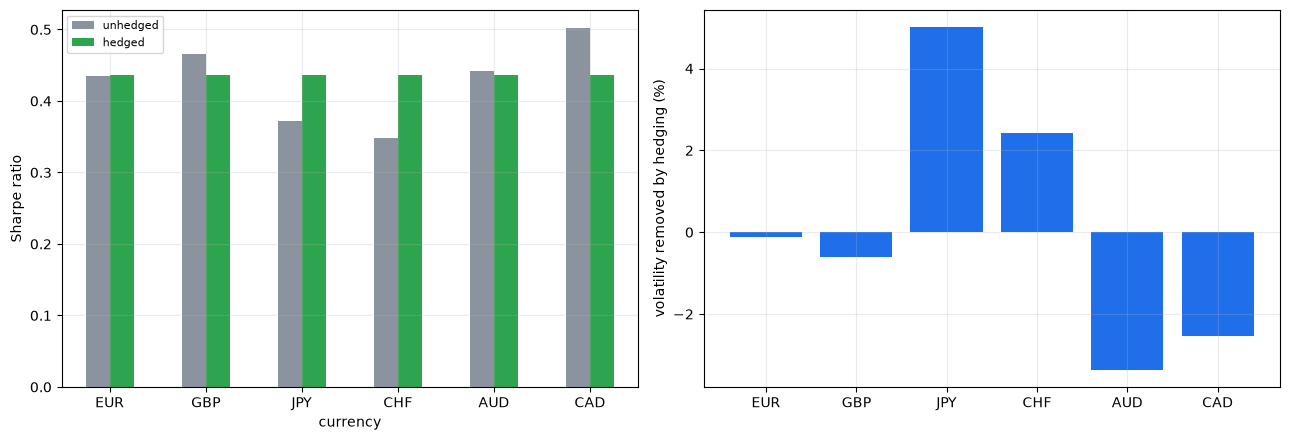

          unhedged  hedged    gain  vol saved  optimal ratio
currency                                                    
EUR         0.4346  0.4366  0.0020    -0.0013         1.5162
GBP         0.4651  0.4366 -0.0285    -0.0062         1.6235
JPY         0.3714  0.4365  0.0651     0.0501         0.3934
CHF         0.3479  0.4366  0.0887     0.0243         1.0008
AUD         0.4413  0.4366 -0.0047    -0.0336         1.8738
CAD         0.5021  0.4366 -0.0656    -0.0253         2.1139


In [7]:
rows = []
for k, f in fx_rets.items():
    ha = st.hedge_analysis(asset, f, usd_rf, cost_bps=3.0)
    t = ha["table"]
    rows.append({"currency": k, "unhedged": ha["unhedged"]["sharpe"],
                 "hedged": t.loc[1.0, "sharpe"], "gain": ha["sharpe_gain"],
                 "vol saved": ha["unhedged"]["vol"] - t.loc[1.0, "vol"],
                 "optimal ratio": ha["optimal_ratio"]})
d = pd.DataFrame(rows).set_index("currency")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
d[["unhedged", "hedged"]].plot.bar(ax=axes[0], color=["#8b949e", "#2ea44f"])
axes[0].set_ylabel("Sharpe ratio"); axes[0].legend(fontsize=8)
plt.setp(axes[0].get_xticklabels(), rotation=0)
axes[1].bar(range(len(d)), d["vol saved"] * 100, color="#1f6feb")
axes[1].set_xticks(range(len(d))); axes[1].set_xticklabels(d.index)
axes[1].set_ylabel("volatility removed by hedging (%)")
plt.tight_layout(); plt.show()
print(d.round(4).to_string())

The hedge reliably removes volatility. Whether it improves the *return* depends on which way the
currency went, which is exactly the thing nobody can forecast — so the honest case for hedging
is the risk one, not the return one.

## 6 · The verdict

**Signal: Weak.** Over 19 years, SPY delivered a Sharpe of **0.46** to a dollar-based investor and anywhere from **0.35** (CHF) to **0.50** (CAD) to investors based elsewhere — a spread of **0.15**, on the identical shares. Three separate channels do the work and they behave differently. The **variance** channel is mechanical: adding a currency leg raised volatility from 19.7% to a median 19.4% because var(a−c) = var(a) + var(c) − 2cov, and the median correlation between SPY and these currencies was only +0.27. The **drift** channel is luck: the dollar happened to move. The **rate** channel is the one nobody adjusts for — each investor's cash leg is their own, and using the US bill rate for everyone (the standard shortcut) biases every high-rate country's Sharpe downward. Across 5 assets the currency moved at least one pair's ranking by **1 places**.

**Tradability: Partial.** Hedging is priced here rather than assumed, because a rolling forward hedge earns the **interest-rate differential** and not zero — selling dollars forward while US rates exceed yours costs you the gap, which is the charge hedged share classes pass on quietly. After that charge, a full hedge raised the Sharpe for **50%** of the currencies here, by a median -0.00. The variance-minimising ratio is not 1.0 either: its median across currencies is **1.57**, because SPY itself co-moves with risk-off currencies, so a full hedge is close to right. The practical reading is that the hedge buys volatility reduction reliably and return unreliably — which is the right way round for a long-horizon holder and the wrong way round for anyone hoping the hedge pays for itself.

## 7 · Going further \U0001F6AA

- **Check the horizon.** Froot (1993) argues real exchange rates mean-revert over decades, so
  the hedge matters far less to a thirty-year holder than to a three-year one.
- **Hedge partially.** The variance-minimising ratio is not 1.0 and is not 0. Campbell et al.
  (2010) compute it properly across a whole portfolio rather than asset by asset.
- **Watch the tax.** Currency gains are taxed differently in every jurisdiction here, sometimes
  as income, which can outweigh everything above.